In [9]:
!pip install opencv-python matplotlib

In [10]:
from google.colab import files
uploaded = files.upload()

Saving input.png.png to input.png.png


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [12]:
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

if img is None:
    print("❌ Image not loaded!")
else:
    img = cv2.resize(img, (500, 400))
    print("✅ Image Loaded")

✅ Image Loaded


In [13]:
# --------- Gamma Correction ---------
gamma = 1.5
invGamma = 1.0 / gamma

table = np.array([((i / 255.0) ** invGamma) * 255
                  for i in np.arange(0, 256)]).astype("uint8")

gamma_corrected = cv2.LUT(img, table)

# --------- CLAHE ---------
lab = cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
cl = clahe.apply(l)

enhanced_lab = cv2.merge((cl, a, b))
enhanced_img = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

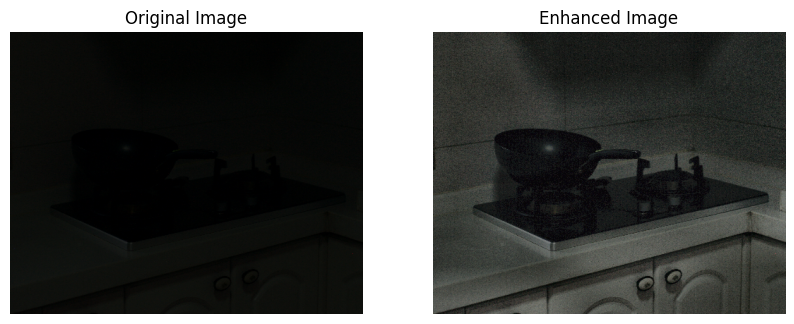

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced Image")
plt.imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

In [15]:
cv2.imwrite("output.jpg", enhanced_img)

from google.colab import files
files.download("output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>